# Data Analysis Internship Project

## Name: Sahil Ashiq
## Domain: Data Analysis  
## Level: 2  

---

### Project Overview

This project focuses on deeper analysis of the restaurant dataset.  
It includes ratings, cuisine combinations, geographic analysis, and restaurant chains.

Python libraries like Pandas and Matplotlib are used for analysis and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("cognifz.csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

### Missing Values

The "Cuisines" column contains some missing values.  
To ensure accurate analysis, I will remove these missing entries from the dataset.


In [6]:
df = df.dropna(subset=['Cuisines'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9542 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9542 non-null   int64  
 1   Restaurant Name       9542 non-null   object 
 2   Country Code          9542 non-null   int64  
 3   City                  9542 non-null   object 
 4   Address               9542 non-null   object 
 5   Locality              9542 non-null   object 
 6   Locality Verbose      9542 non-null   object 
 7   Longitude             9542 non-null   float64
 8   Latitude              9542 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9542 non-null   int64  
 11  Currency              9542 non-null   object 
 12  Has Table booking     9542 non-null   object 
 13  Has Online delivery   9542 non-null   object 
 14  Is delivering now     9542 non-null   object 
 15  Switch to order menu  9542

## Task 1: Restaurant Ratings

### Objective

To analyze the distribution of aggregate ratings, determine the most common rating range, and calculate the average number of votes received by restaurants.


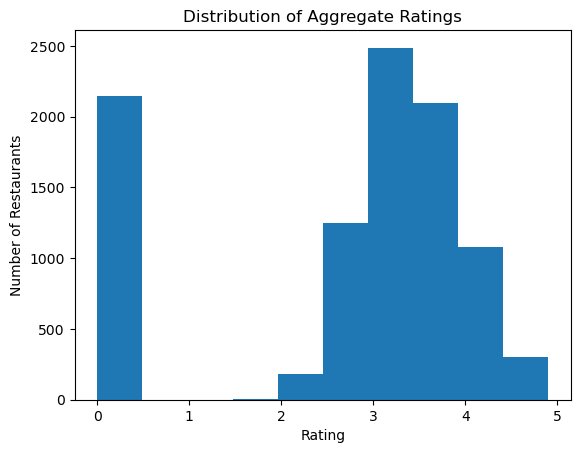

In [9]:
df['Aggregate rating'].plot(kind='hist')
plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.show()

In [11]:
ranges = pd.cut(df['Aggregate rating'], bins=[0,1,2,3,4,5])
count = ranges.value_counts()
top = count.index[0]
print("Most common rating range is:", top)

Most common rating range is: (3, 4]


In [12]:
avg_votes = df['Votes'].mean()
avg_votes = round(avg_votes, 2)
print("Average number of votes received by restaurants:", avg_votes)

Average number of votes received by restaurants: 156.77


### Conclusion

In this task, I visualized the distribution of aggregate ratings using a chart. I found that most restaurants fall in the rating range (3, 4]. I also observed that the average number of votes received by restaurants is 156.77.


## Task 2: Cuisine Combination

### Objective

To identify the most common combinations of cuisines in the dataset and analyze whether certain cuisine combinations tend to have higher ratings.


In [13]:
combo = df['Cuisines'].value_counts()
top = combo.head(5)
print("Top 5 most common cuisine combinations:\n")
for i in top.index:
    print(i, "-", top[i], "restaurants")

Top 5 most common cuisine combinations:

North Indian - 936 restaurants
North Indian, Chinese - 511 restaurants
Chinese - 354 restaurants
Fast Food - 354 restaurants
North Indian, Mughlai - 334 restaurants


In [14]:
rating_combo = df.groupby('Cuisines')['Aggregate rating'].mean()
rating_combo = rating_combo.sort_values(ascending=False)
top_rating = rating_combo.head(5)
print("Top 5 cuisine combinations with highest ratings:\n")
for i in top_rating.index:
    print(i, "- Rating:", round(top_rating[i], 2))

Top 5 cuisine combinations with highest ratings:

Burger, Bar Food, Steak - Rating: 4.9
American, Burger, Grill - Rating: 4.9
American, Caribbean, Seafood - Rating: 4.9
American, Coffee and Tea - Rating: 4.9
Mexican, American, Healthy Food - Rating: 4.9


### Conclusion

In this task, I identified the most common cuisine combinations, where North Indian is the most frequent, followed by combinations like North Indian & Chinese. 

I also observed that some specific cuisine combinations such as Burger, Bar Food, Steak and American-based cuisines have the highest ratings (4.9), indicating better customer preference for these combinations.


## Task 3: Geographic Analysis

### Objective

To plot the locations of restaurants using latitude and longitude and identify patterns or clusters in specific areas.


In [25]:
import folium

sample = df.sample(1000)
m = folium.Map(location=[sample['Latitude'].mean(), sample['Longitude'].mean()], zoom_start=5)

for i in range(len(sample)):
    folium.CircleMarker(
        location=[sample.iloc[i]['Latitude'], sample.iloc[i]['Longitude']],
        radius=2
    ).add_to(m)
m

In [27]:
city_count = df['City'].value_counts()
top_cities = city_count.head(5)
print("Areas with highest concentration of restaurants:\n")
for i in top_cities.index:
    print(i, "-", top_cities[i], "restaurants")

Areas with highest concentration of restaurants:

New Delhi - 5473 restaurants
Gurgaon - 1118 restaurants
Noida - 1080 restaurants
Faridabad - 251 restaurants
Ghaziabad - 25 restaurants


### Conclusion

In this task, I plotted the locations of restaurants on a map using latitude and longitude to understand their geographic distribution.  

I observed that restaurants are highly concentrated in cities like New Delhi (5473 restaurants), Gurgaon (1118), Noida (1080), Faridabad (251), and Ghaziabad (25). 
This shows that New Delhi has the highest concentration of restaurants, followed by Gurgaon and Noida, forming major clusters, while cities like Faridabad and Ghaziabad have comparatively fewer restaurants.


## Task 4: Restaurant Chains

### Objective

To identify restaurant chains in the dataset and analyze their ratings and popularity based on number of restaurants and votes.


In [40]:
chains = df['Restaurant Name'].value_counts()
chains = chains[chains > 1]
t_chains = chains.head(5)
print("Restaurant Chains (Top 5):\n")
count = 1
for i in t_chains.index:
    print(f"{count}. {i:<20} : ({t_chains[i]} outlets)")
    count += 1

Restaurant Chains (Top 5):

1. Cafe Coffee Day      : (83 outlets)
2. Domino's Pizza       : (79 outlets)
3. Subway               : (63 outlets)
4. Green Chick Chop     : (51 outlets)
5. McDonald's           : (48 outlets)


In [45]:
chain_rating = df.groupby('Restaurant Name')['Aggregate rating'].mean()
chain_rating = chain_rating[chain_rating.index.isin(top_chains.index)]
print("\nAverage Ratings of Top Chains:\n")
count = 1
for i in chain_rating.index:
    rating = round(chain_rating[i], 2)
    print(f"{count}. {i:<20} : ({rating} ⭐)")
    count += 1


Average Ratings of Top Chains:

1. Cafe Coffee Day      : (2.42 ⭐)
2. Domino's Pizza       : (2.74 ⭐)
3. Green Chick Chop     : (2.67 ⭐)
4. McDonald's           : (3.34 ⭐)
5. Subway               : (2.91 ⭐)


In [49]:
print("\nAverage Customer Votes (Number of People Who Rated) for Top Chains:\n")
count = 1
for i in chain_votes.index:
    votes = round(chain_votes[i], 2)
    print(f"{count}. {i:<20} : ({votes} votes on average - people rated)")
    count += 1


Average Customer Votes (Number of People Who Rated) for Top Chains:

1. Cafe Coffee Day      : (29.25 votes on average - people rated)
2. Domino's Pizza       : (84.09 votes on average - people rated)
3. Green Chick Chop     : (18.9 votes on average - people rated)
4. McDonald's           : (110.23 votes on average - people rated)
5. Subway               : (97.21 votes on average - people rated)


### Conclusion

In this task, I identified the top restaurant chains in the dataset, where Cafe Coffee Day has the highest number of outlets (83), followed by Domino's Pizza, Subway, Green Chick Chop, and McDonald's.

I analyzed their ratings and found that McDonald's has the highest average rating (3.34 ⭐) among the top chains, while others have relatively lower ratings.

I also examined customer engagement using votes and observed that McDonald's (110.23 votes) and Subway (97.21 votes) receive higher average votes, indicating greater popularity and customer interaction, while chains like Green Chick Chop and Cafe Coffee Day have lower engagement.

Overall, some chains have more outlets, but higher ratings and popularity are seen in specific chains like McDonald's and Subway.


### Final Conclusion 

In Level 2, I analyzed restaurant ratings, cuisine combinations, geographic distribution, and restaurant chains. I found that most restaurants have ratings between 3–4, while some specific cuisine combinations have higher ratings.

I also observed that restaurants are highly concentrated in cities like New Delhi, Gurgaon, and Noida. In terms of chains, Cafe Coffee Day has the most outlets, but McDonald's and Subway show better ratings and customer engagement.

Overall, this analysis helps in understanding restaurant performance and customer preferences.
